<a href="https://colab.research.google.com/github/msmutesa/spiritscript/blob/main/Titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="darkgrid")

In [ ]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

df.head()  # show first 5 rows

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
print(df.isnull().sum())

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [ ]:
# Drop the 'Cabin' column – too many missing values
df.drop('Cabin', axis=1, inplace=True)

# Fill missing 'Age' values with the median age
df['Age'].fillna(df['Age'].median(), inplace=True)

# Drop rows with missing 'Embarked' values
df.dropna(subset=['Embarked'], inplace=True)

# Confirm that there are no more missing values
print(df.isnull().sum())

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipython-input-8-540180445.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [ ]:
# Count how many survived vs not
df['Survived'].value_counts()

,count
Survived,
0,549
1,340


In [ ]:
# Compare survival by gender
df.groupby('Sex')['Survived'].mean()

,Survived
Sex,
female,0.740385
male,0.188908


In [ ]:
# Compare survival by passenger class
df.groupby('Pclass')['Survived'].mean()

,Survived
Pclass,
1,0.626168
2,0.472826
3,0.242363


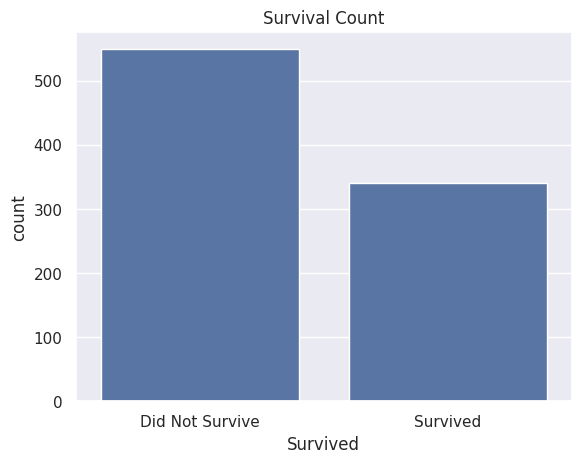

In [ ]:
# Countplot of survival counts
sns.countplot(x='Survived', data=df)
plt.title('Survival Count')
plt.xticks([0, 1], ['Did Not Survive', 'Survived'])
plt.show()

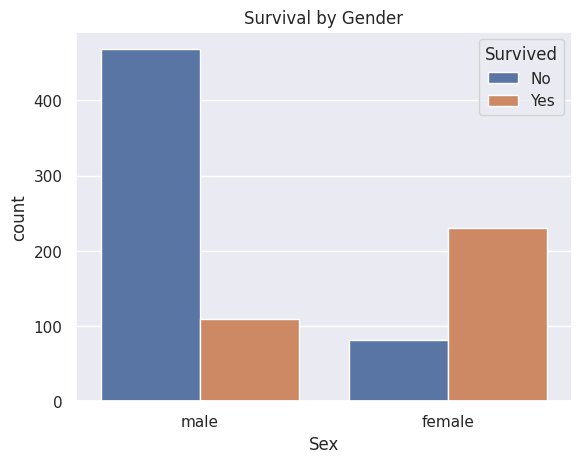

In [ ]:
# Survival count by gender
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Survival by Gender')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

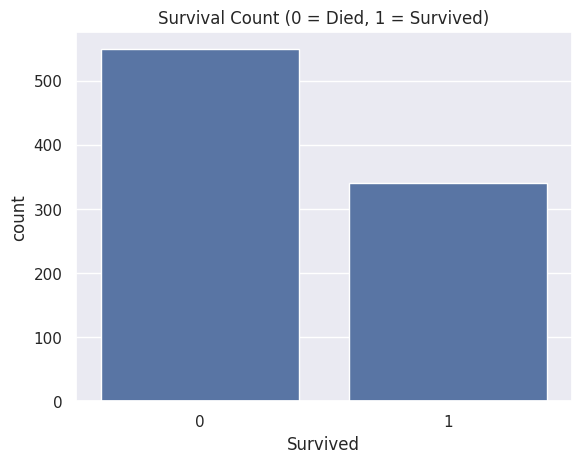

In [16]:
sns.countplot(x='Survived', data=df)
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.show()

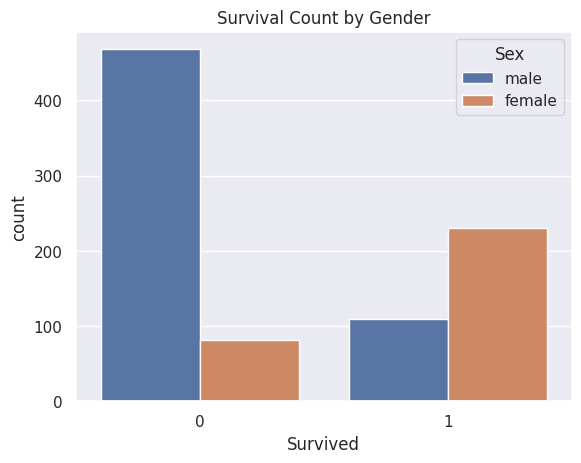

In [17]:
sns.countplot(x='Survived', hue='Sex', data=df)
plt.title('Survival Count by Gender')
plt.show()

In [19]:
# Make a copy so we don’t mess with original
df_numeric = df.copy()

# Convert categorical features to numeric
df_numeric['Sex'] = df_numeric['Sex'].map({'male': 0, 'female': 1})
df_numeric['Embarked'] = df_numeric['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

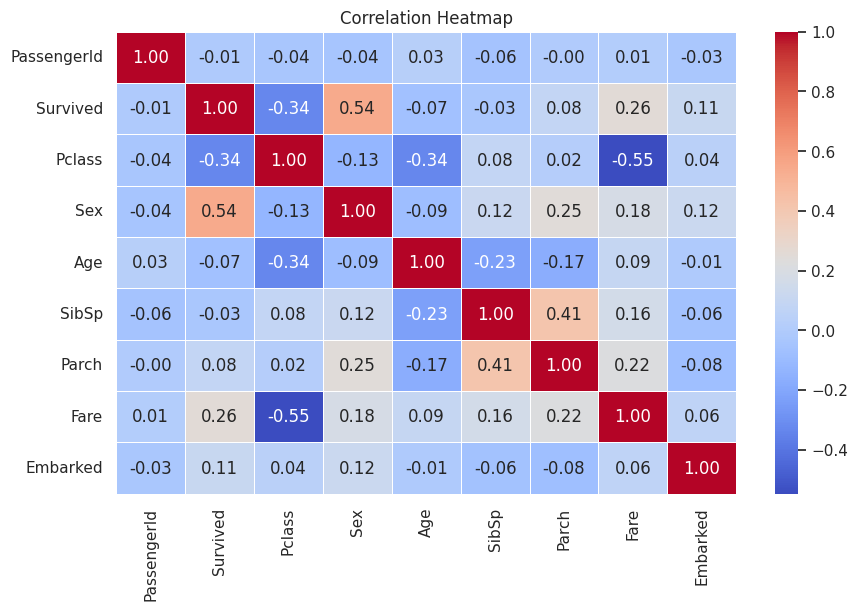

In [21]:
# Drop columns that are still strings
df_corr = df_numeric.drop(['Name', 'Ticket'], axis=1)

# Plot correlation heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df_corr.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

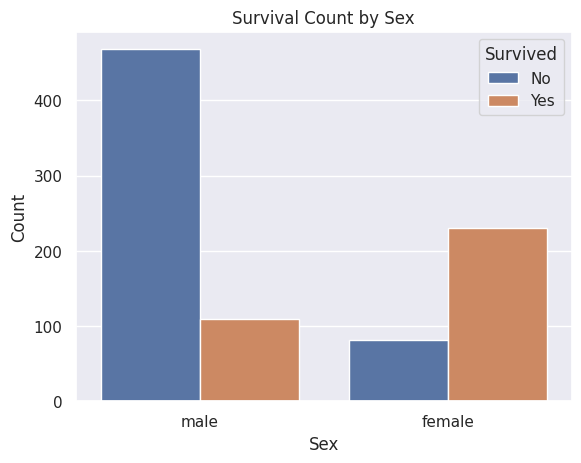

In [22]:
sns.countplot(data=df, x='Sex', hue='Survived')
plt.title('Survival Count by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

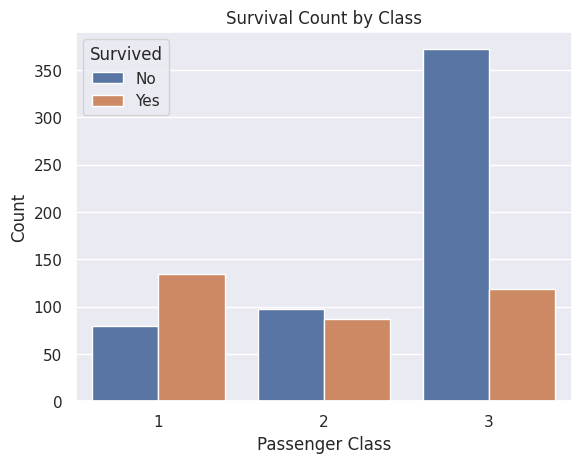

In [23]:
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.title('Survival Count by Class')
plt.xlabel('Passenger Class')
plt.ylabel('Count')
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

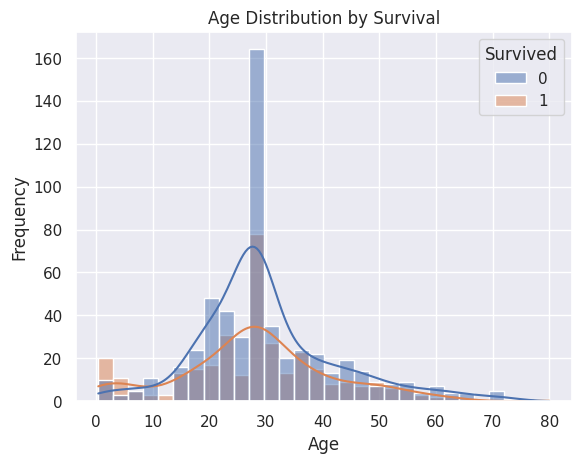

In [24]:
sns.histplot(data=df, x='Age', hue='Survived', kde=True, bins=30)
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

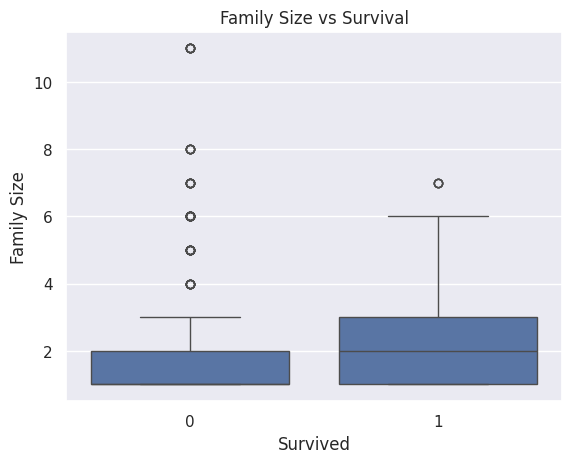

In [25]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

sns.boxplot(data=df, x='Survived', y='FamilySize')
plt.title('Family Size vs Survival')
plt.xlabel('Survived')
plt.ylabel('Family Size')
plt.show()